In [98]:
import pandas as pd
import matplotlib as plt
import datetime
import numpy as np
from pylab import pcolor, show, colorbar, xticks, yticks, arange

In [85]:
appl = pd.read_csv("C:/assigmentsdb/3250_Assignment 3_aapl.csv", index_col = 'Date', parse_dates = True)
amzn = pd.read_csv("C:/assigmentsdb/3250_Assignment 3_amzn.csv", index_col = 'Date', parse_dates = True)
ebay = pd.read_csv("C:/assigmentsdb/3250_Assignment 3_ebay.csv", index_col = 'Date', parse_dates = True)
intc = pd.read_csv("C:/assigmentsdb/3250_Assignment 3_INTC.csv", index_col = 'Date', parse_dates = True)
intc.columns

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'ExDividend', 'SplitRatio',
       'AdjOpen', 'AdjHigh', 'AdjLow', 'AdjClose', 'AdjVolume'],
      dtype='object')

**Monthend Close Price**

In [86]:
appl_adj = appl['Adj Close']
amzn_adj = amzn['Adj Close']
ebay_adj = ebay['AdjClose']
intc_adj = intc['AdjClose']
appl_monthly = appl_adj.resample('ME').last()
amzn_monthly = amzn_adj.resample('ME').last()
ebay_monthly = ebay_adj.resample('ME').last()
intc_monthly = intc_adj.resample('ME').last()

In [87]:
print(f'APPL Monthend Close Price: {appl_monthly}')

APPL Monthend Close Price: Date
2013-02-28     47.371712
2013-03-31     47.506943
2013-04-30     47.519821
2013-05-31     50.594505
2013-06-30     44.609531
                 ...    
2017-10-31    167.750549
2017-11-30    171.152191
2017-12-31    168.542831
2018-01-31    166.750137
2018-02-28    178.119995
Freq: ME, Name: Adj Close, Length: 61, dtype: float64


**Use pandas autocorrelation_plot() function to plot the autocorrelation of the month-end close prices of each of the stocks.  Are they autocorrelated?  Why or why not?** 

Yes, the prices are autocorrelated. This can be seen in the values starting high and remaining above the significance level for several lags. Stock prices usually follow trends; they depend on their previous prices.

In [88]:
# pd.plotting.autocorrelation_plot(appl_monthly)
# pd.plotting.autocorrelation_plot(amzn_monthly)
# pd.plotting.autocorrelation_plot(ebay_monthly)
# pd.plotting.autocorrelation_plot(intc_monthly)

**Calculate the monthly return over the period for each stock using the “shift trick” on the lecture slide titled Shifting (Note: you should end up with a time series 59 months long)**

In [89]:
appl_return = (appl_monthly / appl_monthly.shift(1)) - 1
appl_return.dropna()
amzn_return = (amzn_monthly / amzn_monthly.shift(1)) - 1
amzn_return.dropna()
intc_return = (intc_monthly / intc_monthly.shift(1)) - 1
intc_return.dropna()
ebay_return = (ebay_monthly / ebay_monthly.shift(1)) - 1
ebay_return.dropna()
None

**Plot the autocorrelation of the monthly returns.  Are they autocorrelated?  Why or why not?**

No, they are not. In the plot, the values follow a straight line within the dashed lines, showing that the return is unpredictable and not correlated with the past month. 

In [90]:
# pd.plotting.autocorrelation_plot(appl_return)
# pd.plotting.autocorrelation_plot(amzn_return)
# pd.plotting.autocorrelation_plot(ebay_return)
# pd.plotting.autocorrelation_plot(intc_return)

**Visualize the correlation between the returns of all pairs of stocks using a scatterplot matrix**

In [91]:
returns = pd.DataFrame({
    'AAPL': appl_return,
    'AMZN': amzn_return,
    'EBAY': ebay_return,
    'INTC': intc_return
})

array([[<Axes: xlabel='AAPL', ylabel='AAPL'>,
        <Axes: xlabel='AMZN', ylabel='AAPL'>,
        <Axes: xlabel='EBAY', ylabel='AAPL'>,
        <Axes: xlabel='INTC', ylabel='AAPL'>],
       [<Axes: xlabel='AAPL', ylabel='AMZN'>,
        <Axes: xlabel='AMZN', ylabel='AMZN'>,
        <Axes: xlabel='EBAY', ylabel='AMZN'>,
        <Axes: xlabel='INTC', ylabel='AMZN'>],
       [<Axes: xlabel='AAPL', ylabel='EBAY'>,
        <Axes: xlabel='AMZN', ylabel='EBAY'>,
        <Axes: xlabel='EBAY', ylabel='EBAY'>,
        <Axes: xlabel='INTC', ylabel='EBAY'>],
       [<Axes: xlabel='AAPL', ylabel='INTC'>,
        <Axes: xlabel='AMZN', ylabel='INTC'>,
        <Axes: xlabel='EBAY', ylabel='INTC'>,
        <Axes: xlabel='INTC', ylabel='INTC'>]], dtype=object)

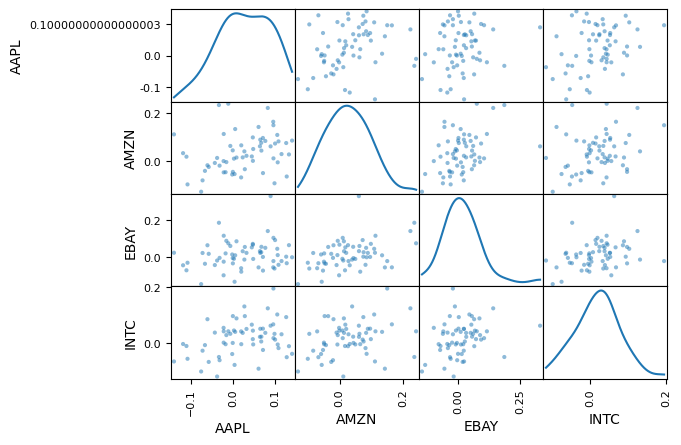

In [92]:
pd.plotting.scatter_matrix(returns, diagonal='kde')

**Following the instructions in the article The Glowing Python to an external site. Visualize the correlation of the returns of all pairs of stocks**

I am having some problems with the plot; it keeps showing nothing on the values.

In [104]:
data = np.array([appl_return.values, amzn_return.values, ebay_return.values, intc_return.values])

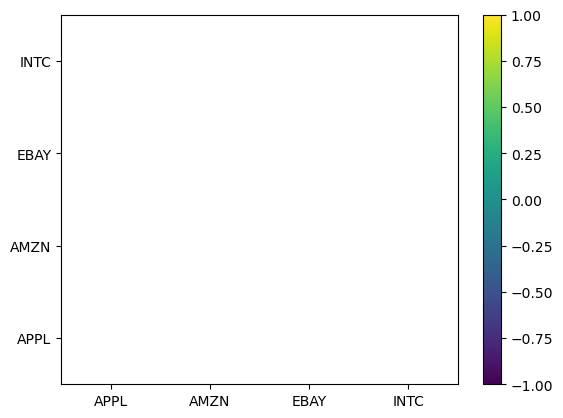

In [105]:
R = np.corrcoef(data)
pcolor(R, vmin=-1, vmax=1)
colorbar()
labels = ['APPL', 'AMZN', 'EBAY', 'INTC']
yticks(arange(0.5,4.5),labels)
xticks(arange(0.5,4.5),labels)
show()